In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("vipullrathod/fish-market")

# print("Path to dataset files:", path)

In [2]:
# !pip install torch torchvision numpy matplotlib seaborn scikit-learn jupyter

### Importing required libraries

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cpu
PyTorch version: 2.12.1+cpu


### Loading Dataset

In [4]:
df = pd.read_csv("Fish.csv")

In [5]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 8.8 KB


In [7]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='str')

In [8]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [9]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [10]:
df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


Text(0.5, 1.0, 'Feature Correlation Matrix')

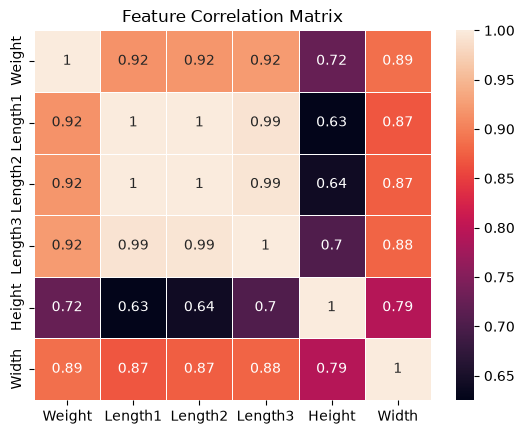

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot = True, linewidths=0.5)
plt.title("Feature Correlation Matrix")

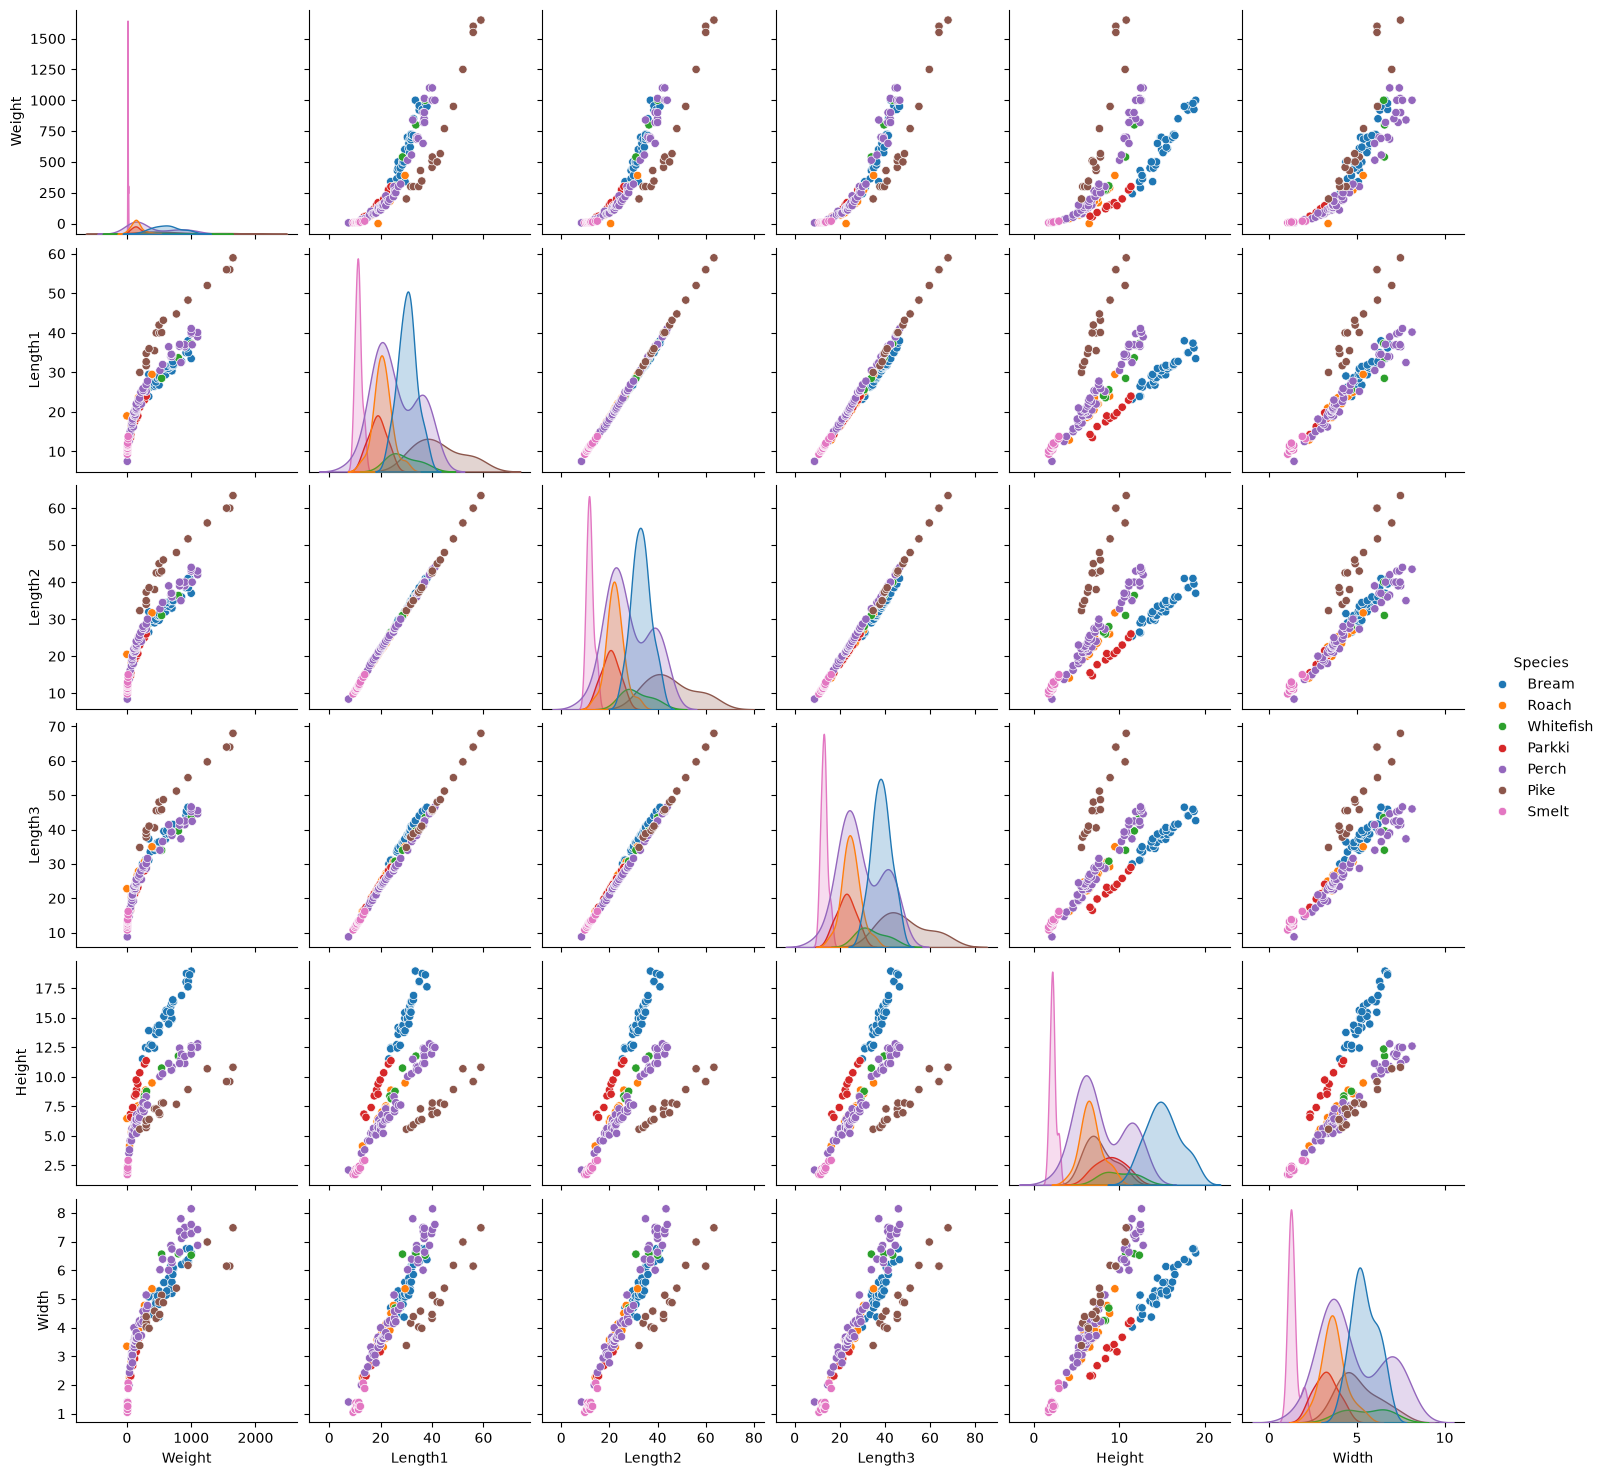

In [12]:
sns.pairplot(df, hue = 'Species')

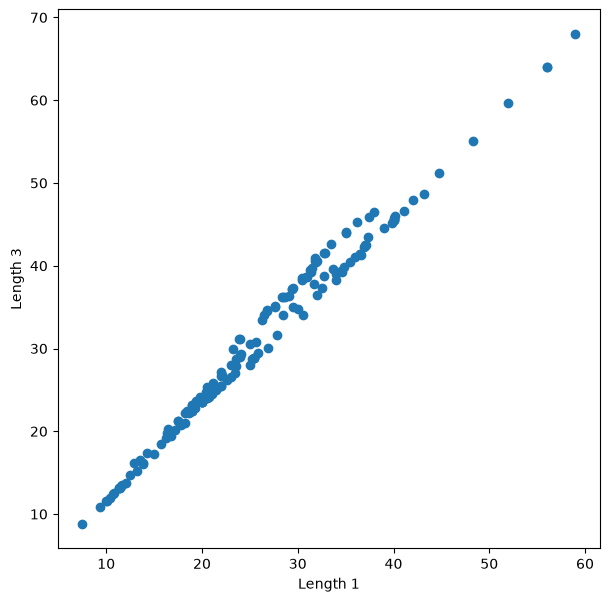

In [13]:
X = df[['Length1']].values
Y = df[['Length3']].values

plt.figure(figsize = (7,7))
plt.scatter(x = X, y = Y)
plt.xlabel("Length 1")
plt.ylabel("Length 3")
plt.show()

### Train/ Test Split and Dataloaders

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], Y[:train_split]
X_test, y_test = X[train_split:], Y[train_split:]

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

batch_size = 8 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
import torch.nn as nn
import warnings 
warnings.filterwarnings('ignore')

In [16]:
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()

        # linear function
        self.weight = nn.Parameter(torch.randn(1, requires_grad = True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad = True))

    # forward pass
    def forward(self, x_tensor):
        # The forward pass: y = weight * x + bias
        return self.weight * x_tensor * self.bias

#### R2 Loss

In [17]:
# define model
model = LinearRegression()
print(f"Initial parameters: weight = {model.weight.item():.4f}, bias = {model.bias.item():.4f}")

# MSE
loss_fn = nn.MSELoss()

# Optimization and Hyperparameters
lr = 0.00
optimizer = torch.optim.SGD(model.parameters(), lr = lr)
epochs = 1001

Initial parameters: weight = 0.3367, bias = 0.1288


#### Training Loop with R2

In [18]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # Forward pass
        predictions = model(X_batch)
        # Calculate loss
        loss = loss_fn(predictions, y_batch)
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Accumulate loss
        train_loss += loss.item()

    # Calculate average training loss for the epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Testing phase (Evaluation)
    model.eval()
    test_loss = 0.0
    with torch.inference_mode():  # Disable gradient tracking for inference
        for X_batch, y_batch in test_loader:
            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{epochs} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")


Epoch  50/1001 | Train Loss: 950.417576 | Test Loss: 1347.526905
Epoch 100/1001 | Train Loss: 950.350861 | Test Loss: 1347.526905
Epoch 150/1001 | Train Loss: 947.702320 | Test Loss: 1347.526905
Epoch 200/1001 | Train Loss: 950.021904 | Test Loss: 1347.526905
Epoch 250/1001 | Train Loss: 950.829826 | Test Loss: 1347.526905
Epoch 300/1001 | Train Loss: 948.987179 | Test Loss: 1347.526905
Epoch 350/1001 | Train Loss: 950.095531 | Test Loss: 1347.526905
Epoch 400/1001 | Train Loss: 948.941671 | Test Loss: 1347.526905
Epoch 450/1001 | Train Loss: 948.114788 | Test Loss: 1347.526905
Epoch 500/1001 | Train Loss: 949.595306 | Test Loss: 1347.526905
Epoch 550/1001 | Train Loss: 952.097950 | Test Loss: 1347.526905
Epoch 600/1001 | Train Loss: 948.274632 | Test Loss: 1347.526905
Epoch 650/1001 | Train Loss: 947.795063 | Test Loss: 1347.526905
Epoch 700/1001 | Train Loss: 950.615559 | Test Loss: 1347.526905
Epoch 750/1001 | Train Loss: 950.242378 | Test Loss: 1347.526905
Epoch 800/1001 | Train Lo

### Evaluation & Visualization

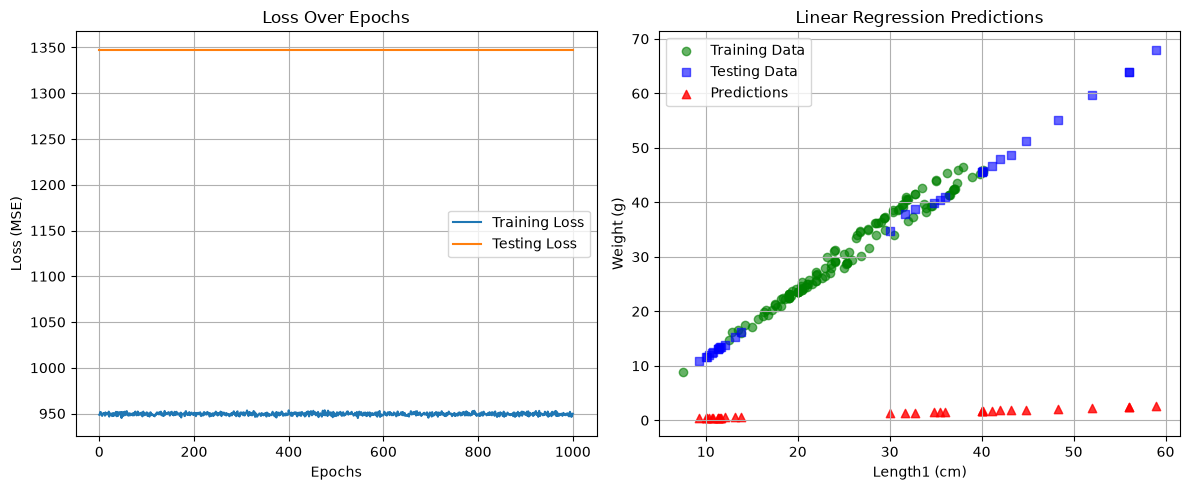

In [19]:
# Plot training and testing loss over epochs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(epochs), train_losses, label='Training Loss')
plt.plot(range(epochs), test_losses, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Loss Over Epochs')
plt.grid(True)

# Plot predictions vs actual data (using the structure from the PDF guide)
plt.subplot(1, 2, 2)
# Convert test tensors back to numpy for plotting
X_test_np = X_test_t.numpy()
y_test_np = y_test_t.numpy()

# Get model predictions for the test set
with torch.inference_mode():
    predictions = model(X_test_t)
predictions_np = predictions.numpy()

plt.scatter(X_train, y_train, c='green', label='Training Data', marker='o', alpha=0.6)
plt.scatter(X_test_np, y_test_np, c='blue', label='Testing Data', marker='s', alpha=0.6)
plt.scatter(X_test_np, predictions_np, c='red', label='Predictions', marker='^', alpha=0.8)
plt.xlabel('Length1 (cm)')
plt.ylabel('Weight (g)')
plt.legend()
plt.title('Linear Regression Predictions')
plt.grid(True)

plt.tight_layout()
plt.show()


#### Final Model Parameters for R2

In [20]:
print(f"Final model parameters:")
print(f"  Weight: {model.weight.item():.4f}")
print(f"  Bias:   {model.bias.item():.4f}")

# Calculate R-squared score on test data for model performance
from sklearn.metrics import r2_score
with torch.inference_mode():
    final_predictions = model(X_test_t).numpy()

r2 = r2_score(y_test, final_predictions)
print(f"R-squared on test set: {r2:.4f}")


Final model parameters:
  Weight: 0.3367
  Bias:   0.1288
R-squared on test set: -2.7029


#### Huber Loss

In [21]:
class HuberLoss(nn.Module):
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, predictions, targets):
        residuals = predictions - targets
        abs_res = torch.abs(residuals)
        quadratic = 0.5 * residuals**2
        linear = self.delta * abs_res - 0.5 * self.delta**2
        loss = torch.where(abs_res <= self.delta, quadratic, linear)
        return torch.mean(loss)

In [22]:
model_huber = LinearRegression()
print(f"Initial parameters: weight = {model_huber.weight.item():.4f}, bias = {model_huber.bias.item():.4f}")

# Huber Loss
loss_fn_huber = HuberLoss(delta=1.0)

# Optimization and Hyperparameters
lr_huber = 0.001
optimizer_huber = torch.optim.Adam(model_huber.parameters(), lr=lr_huber)
epochs_huber = 1000


Initial parameters: weight = -0.9685, bias = -1.1212


#### Training Loop with Huber Loss

In [23]:
train_losses_huber = []
test_losses_huber = []

for epoch in range(epochs_huber):
    # Training phase
    model_huber.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # Forward pass
        predictions = model_huber(X_batch)
        # Calculate loss using Huber
        loss = loss_fn_huber(predictions, y_batch)
        # Backward pass and optimization
        optimizer_huber.zero_grad()
        loss.backward()
        optimizer_huber.step()
        # Accumulate loss
        train_loss += loss.item()

    # Calculate average training loss for the epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses_huber.append(avg_train_loss)

    # Testing phase (Evaluation)
    model_huber.eval()
    test_loss = 0.0
    with torch.inference_mode():
        for X_batch, y_batch in test_loader:
            predictions = model_huber(X_batch)
            loss = loss_fn_huber(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses_huber.append(avg_test_loss)

    # Print progress every 50 epochs
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{epochs_huber} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")


Epoch  50/1000 | Train Loss: 0.808579 | Test Loss: 1.058827
Epoch 100/1000 | Train Loss: 0.812401 | Test Loss: 0.936931
Epoch 150/1000 | Train Loss: 0.810803 | Test Loss: 1.000216
Epoch 200/1000 | Train Loss: 0.810157 | Test Loss: 1.033268
Epoch 250/1000 | Train Loss: 0.808635 | Test Loss: 1.034728
Epoch 300/1000 | Train Loss: 0.816468 | Test Loss: 1.127427
Epoch 350/1000 | Train Loss: 0.809771 | Test Loss: 0.951451
Epoch 400/1000 | Train Loss: 0.810476 | Test Loss: 0.989637
Epoch 450/1000 | Train Loss: 0.804825 | Test Loss: 1.026684
Epoch 500/1000 | Train Loss: 0.808271 | Test Loss: 1.052368
Epoch 550/1000 | Train Loss: 0.805781 | Test Loss: 0.967005
Epoch 600/1000 | Train Loss: 0.807635 | Test Loss: 1.008037
Epoch 650/1000 | Train Loss: 0.807716 | Test Loss: 1.095467
Epoch 700/1000 | Train Loss: 0.807189 | Test Loss: 1.019018
Epoch 750/1000 | Train Loss: 0.813611 | Test Loss: 1.115298
Epoch 800/1000 | Train Loss: 0.812007 | Test Loss: 0.940658
Epoch 850/1000 | Train Loss: 0.805584 | 

#### Evaluation and Visualization

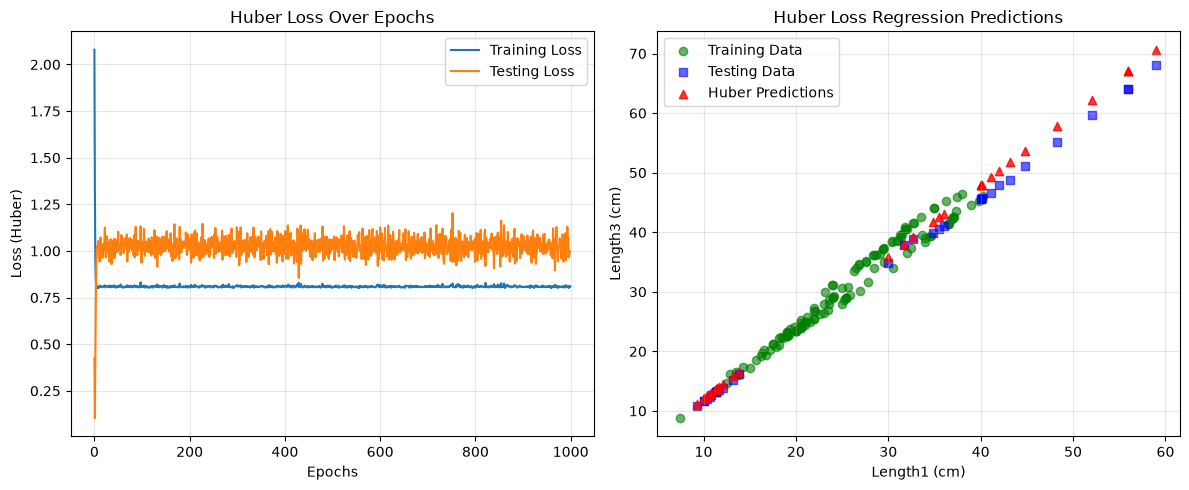

In [24]:
plt.figure(figsize=(12, 5))

# Plot training and testing loss over epochs for Huber model
plt.subplot(1, 2, 1)
plt.plot(range(epochs_huber), train_losses_huber, label='Training Loss')
plt.plot(range(epochs_huber), test_losses_huber, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.title('Huber Loss Over Epochs')
plt.grid(True, alpha=0.3)

# Plot predictions vs actual data for Huber model
plt.subplot(1, 2, 2)
X_test_np = X_test_t.numpy()
y_test_np = y_test_t.numpy()

with torch.inference_mode():
    predictions_huber = model_huber(X_test_t)
predictions_np_huber = predictions_huber.numpy()

plt.scatter(X_train, y_train, c='green', label='Training Data', marker='o', alpha=0.6)
plt.scatter(X_test_np, y_test_np, c='blue', label='Testing Data', marker='s', alpha=0.6)
plt.scatter(X_test_np, predictions_np_huber, c='red', label='Huber Predictions', marker='^', alpha=0.8)
plt.xlabel('Length1 (cm)')
plt.ylabel('Length3 (cm)')
plt.legend()
plt.title('Huber Loss Regression Predictions')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Final Model Parameters (Huber)

In [25]:
print(f"\nFinal Huber model parameters:")
print(f"  Weight: {model_huber.weight.item():.4f}")
print(f"  Bias:   {model_huber.bias.item():.4f}")

# Calculate R-squared score on test data for Huber model
with torch.inference_mode():
    final_predictions_huber = model_huber(X_test_t).numpy()

r2_huber = r2_score(y_test, final_predictions_huber)
print(f"R-squared on test set: {r2_huber:.4f}")



Final Huber model parameters:
  Weight: -1.0207
  Bias:   -1.1729
R-squared on test set: 0.9915


#### Compare


=== Training Comparison: MSE vs Huber Loss ===

Epoch   0: MSE=3916.1553, Huber=22.6080
Epoch  50: MSE=938.6075, Huber=1.0813
Epoch 100: MSE=9.0764, Huber=1.1163
Epoch 150: MSE=3.3285, Huber=1.1417
Epoch 200: MSE=3.4161, Huber=0.9289
Epoch 250: MSE=3.4300, Huber=0.9852
Epoch 300: MSE=3.4631, Huber=1.0593
Epoch 350: MSE=3.6156, Huber=0.8935
Epoch 400: MSE=3.5138, Huber=1.0414
Epoch 450: MSE=3.5655, Huber=0.9909


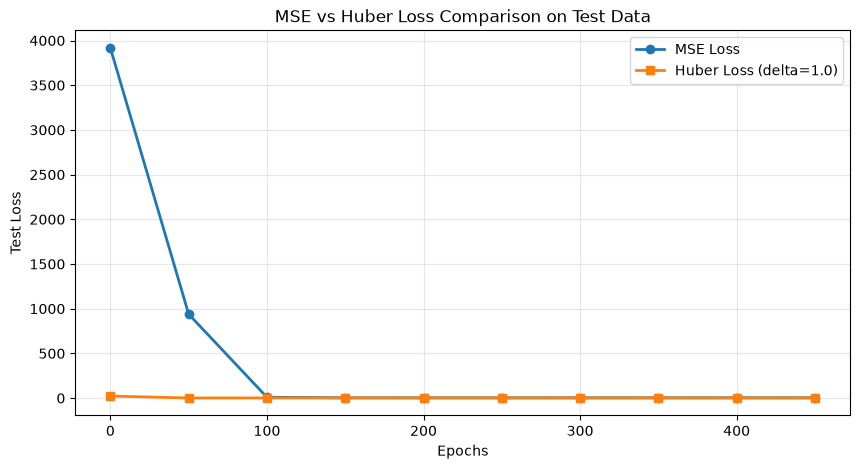


=== Summary Statistics ===
MSE Model - Final Test Loss: 3.5655
Huber Model - Final Test Loss: 0.9909


In [26]:
def compare_loss_functions():
    """Compare MSE vs Huber Loss performance"""
    
    # Train with MSE (using the already trained model from earlier)
    # If you didn't run the MSE training earlier, you can train it here
    # For this comparison, we'll use the existing model from the notebook
    
    # Train a fresh model with MSE for fair comparison
    model_mse_compare = LinearRegression()
    optimizer_mse_compare = torch.optim.Adam(model_mse_compare.parameters(), lr=0.001)
    mse_loss_fn = nn.MSELoss()
    
    # Train a fresh model with Huber
    model_huber_compare = LinearRegression()
    optimizer_huber_compare = torch.optim.Adam(model_huber_compare.parameters(), lr=0.001)
    huber_loss_fn = HuberLoss(delta=1.0)
    
    mse_hist, huber_hist = [], []
    mse_test_losses, huber_test_losses = [], []
    
    print("\n=== Training Comparison: MSE vs Huber Loss ===\n")
    
    for epoch in range(500):
        # Train MSE model
        model_mse_compare.train()
        for X_batch, y_batch in train_loader:
            pred = model_mse_compare(X_batch)
            loss = mse_loss_fn(pred, y_batch)
            optimizer_mse_compare.zero_grad()
            loss.backward()
            optimizer_mse_compare.step()
        
        # Train Huber model
        model_huber_compare.train()
        for X_batch, y_batch in train_loader:
            pred = model_huber_compare(X_batch)
            loss = huber_loss_fn(pred, y_batch)
            optimizer_huber_compare.zero_grad()
            loss.backward()
            optimizer_huber_compare.step()
        
        # Record losses every 50 epochs
        if epoch % 50 == 0:
            with torch.inference_mode():
                mse_test = mse_loss_fn(model_mse_compare(X_test_t), y_test_t).item()
                huber_test = huber_loss_fn(model_huber_compare(X_test_t), y_test_t).item()
                mse_hist.append(mse_test)
                huber_hist.append(huber_test)
                mse_test_losses.append(mse_test)
                huber_test_losses.append(huber_test)
                print(f"Epoch {epoch:>3}: MSE={mse_test:.4f}, Huber={huber_test:.4f}")
    
    # Plot comparison
    plt.figure(figsize=(10, 5))
    plt.plot(range(0, 500, 50), mse_hist, label='MSE Loss', marker='o', linewidth=2)
    plt.plot(range(0, 500, 50), huber_hist, label='Huber Loss (delta=1.0)', marker='s', linewidth=2)
    plt.xlabel('Epochs')
    plt.ylabel('Test Loss')
    plt.legend()
    plt.title('MSE vs Huber Loss Comparison on Test Data')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Print summary statistics
    print("\n=== Summary Statistics ===")
    print(f"MSE Model - Final Test Loss: {mse_test_losses[-1]:.4f}")
    print(f"Huber Model - Final Test Loss: {huber_test_losses[-1]:.4f}")
    
    return mse_test_losses, huber_test_losses


# =============================================
# 5. Run the Comparison
# =============================================

# Call the comparison function
mse_losses, huber_losses = compare_loss_functions()


### Save Model

In [27]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save MSE Model
MSE_MODEL_NAME = "fish_length_weight_model_mse.pth"
MSE_SAVE_PATH = MODEL_PATH / MSE_MODEL_NAME
torch.save(model.state_dict(), MSE_SAVE_PATH)
print(f"MSE Model saved to {MSE_SAVE_PATH}")

# Save Huber Model
HUBER_MODEL_NAME = "fish_length_weight_model_huber.pth"
HUBER_SAVE_PATH = MODEL_PATH / HUBER_MODEL_NAME
torch.save(model_huber.state_dict(), HUBER_SAVE_PATH)
print(f"Huber Model saved to {HUBER_SAVE_PATH}")


MSE Model saved to models\fish_length_weight_model_mse.pth
Huber Model saved to models\fish_length_weight_model_huber.pth


In [28]:
def load_mse_model():
    """Load the saved MSE model"""
    loaded_model = LinearRegression()
    loaded_model.load_state_dict(torch.load(MSE_SAVE_PATH))
    loaded_model.eval()
    return loaded_model

def load_huber_model():
    """Load the saved Huber model"""
    loaded_model = LinearRegression()
    loaded_model.load_state_dict(torch.load(HUBER_SAVE_PATH))
    loaded_model.eval()
    return loaded_model


In [29]:
# Test the loaded models with sample predictions
def test_loaded_models():
    """Test that loaded models work correctly"""
    
    # Load models
    mse_loaded = load_mse_model()
    huber_loaded = load_huber_model()
    
    # Test predictions
    test_lengths = [20.0, 25.0, 30.0, 35.0, 40.0]
    
    print("\n=== Testing Loaded Models ===")
    print("Length (cm) | MSE Prediction | Huber Prediction")
    print("-" * 50)
    
    for length in test_lengths:
        input_tensor = torch.tensor([[length]], dtype=torch.float32)
        
        with torch.inference_mode():
            mse_pred = mse_loaded(input_tensor).item()
            huber_pred = huber_loaded(input_tensor).item()
        
        print(f"{length:>10} | {mse_pred:>14.4f} | {huber_pred:>16.4f}")

# Uncomment to test
test_loaded_models()



=== Testing Loaded Models ===
Length (cm) | MSE Prediction | Huber Prediction
--------------------------------------------------
      20.0 |         0.8674 |          23.9437
      25.0 |         1.0842 |          29.9296
      30.0 |         1.3011 |          35.9155
      35.0 |         1.5179 |          41.9014
      40.0 |         1.7348 |          47.8873
